# Gait report — one recording, one user, one surface, or everything

Reproduces the stappone dashboard metrics from the raw insole files, over any set of
recordings, and aggregates by user, by surface, or overall.

Expected layout, with this notebook in `notebooks/`:

```
WalkSensePlace/
├── notebooks/                 <- this file
├── Individual Users/<user>/   REC_*.csv
├── Ground Contact/<user>/     REC_*_groundcontact.csv
├── grass_dry.csv, loose_dry.csv, paved_dry.csv
└── insole_42_complete_380p.png
```

**What is reproduced, verified against three report PDFs** (sessions 20260820-154156,
20260819-144831, 20260813-182941): steps to within 1, duration to 0.2 s, gait cycle
exactly, cadence exactly, stance and swing exactly once you account for the display
rounding, double support, Overall pressure share to within a point, the per-sensor
pressure map, and the cyclogram.

**What is not**: the medial/lateral and forefoot/hindfoot panels. Those move 25 points
across three recordings whose measured pressure maps agree to ~1 part in 100, so they are
not a repeatable measurement — see section 8. This notebook computes its own, by the
manual's 50 %-of-length divider, and reports them as such.


## 1. Configuration

In [56]:
import json, os, re, glob
from pathlib import Path

import matplotlib as mpl
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import ndimage as ndi

# ── where things live ───────────────────────────────────────────────────────
BASE      = Path('..')                      # the WalkSensePlace folder
RAW_DIR   = BASE / 'Individual Users'       # <user>/REC_*.csv
GC_DIR    = BASE / 'Ground Contact'         # <user>/REC_*_groundcontact.csv
ASSET_DIR = BASE                            # insole png + cop_coords.py
OUT_DIR   = Path('figures'); OUT_DIR.mkdir(parents=True, exist_ok=True)
INSOLE_PNG = ASSET_DIR / 'insole_42_complete_380p.png'
COORDS_PY  = ASSET_DIR / 'cop_coords.py'

# ── what to include ────────────────────────────────────────────────────────
USERS       = None      # None = every folder under RAW_DIR; else e.g. ['Sam', 'Kristian']
RECORDINGS  = None      # None = all; else a list of stems, e.g. ['REC_20260820_154156']
REQUIRE_EVENTS = True   # skip recordings with no *_groundcontact.csv (see section 3)

# ---- distance ---------------------------------------------------------------
# distance.csv holds stappone's own PRE-FILLED estimates from the website's data page,
# not GPS ground truth. They behave as steps x a per-walker constant with 2-5% scatter
# that nothing measurable explains (implied stride correlates with cadence at r=+0.014,
# with cycle time at r=-0.006), so treat anything derived from them as carrying an
# unknown error, and validate against your GPX tracks before publishing.
#
# For a group that splits a recording - anything grouped by surface - the recording's
# distance is APPORTIONED by that group's share of the recording's kept steps. That
# assumes stride length is constant within a recording, which is the defensible choice:
#
#   - a per-stride ZUPT integration was tried, so that the apportionment could follow
#     measured stride lengths. Absolute accuracy was never the issue (a constant scale
#     error cancels when a known total is distributed), but the RELATIVE estimate is too
#     noisy to use: per-stride scatter is 33-43% while the surface-level differences it
#     would need to resolve are 1-4% (normalised within recording: grass 0.957,
#     loose 1.011, paved 1.002, n = 150/455/714). Apportioning by it would add noise,
#     not information.
#
# Consequence worth understanding: velocity per surface IS meaningful, because it is
# apportioned distance over measured duration, which reduces to a constant stride times
# the measured cadence. Stride length per surface is NOT - it is constant by
# construction - so it is reported only for whole recordings.
DISTANCE_CSV = BASE / 'distance.csv'

SOLE_ID  = {'right': 1, 'left': 2}          # per the stappone manual
SOLE_W_MM, SOLE_L_MM = 106.3, 271.3         # size 42 outline, used for drawing only

# ── surface tags ───────────────────────────────────────────────────────────
SURFACE_MAP = {
    'grass': 'grass',
    'dirt': 'loose', 'compact ground': 'loose', 'compacted ground': 'loose',
    'gravel': 'loose', 'sand': 'loose', 'rocks': 'loose',
    'concrete': 'paved', 'asphalt': 'paved', 'exposed aggregate': 'paved',
    'brick': 'paved', 'cobblestone': 'paved', 'uneven brick': 'paved',
}
EXCLUDE_TAGS  = ['transition', 'wait']
EXCLUDE_LABEL = '__exclude__'

# STRICT exclusion. A transition/wait tag opens a region that runs to the next surface
# tag (or the end of the recording). ANY step overlapping that region by even one sample
# is dropped, and so is any step spanning two surfaces. There is no partial-coverage
# threshold: unlike the 80 %-labelled rule used in the model notebooks, a step here is
# either wholly inside one labelled surface or it is discarded.
DROP_UNLABELLED = True   # also drop steps with no surface tag at all

# ── stance detection fallback (only used when no event file exists) ────────
HEEL_SENSORS = ['pressure_08', 'pressure_11']
ALL_SENSORS  = [f'pressure_{i:02d}' for i in range(1, 13)]
BASE_PCT = 2.0
LOW_PCT, HIGH_PCT, CONTACT_FRAC, MIN_STANCE_SAMPLES = 5, 95, 0.15, 5
CYCLE_RANGE_S = (0.5, 2.0)

# ── regularity ─────────────────────────────────────────────────────────────
REG_SOURCE, REG_TRIM_PCT = 'left', 0.0      # see section 6

mpl.rcParams.update({'figure.dpi': 130, 'savefig.dpi': 220, 'font.size': 9})
BASE_COLS = set(['sole_id', 'timestamp', 'accel_x', 'accel_y', 'accel_z', 'gyro_x',
                 'gyro_y', 'gyro_z', 'magn_x', 'magn_y', 'magn_z', 'corrupt']
                + ALL_SENSORS)

## 2. Sensor geometry and insole artwork

In [57]:
COORDS_LEFT = np.array([[0.7438, 0.8713], [0.7979, 0.7165], [0.6264, 0.5308],
                        [0.4839, 0.7074], [0.6441, 0.7103], [0.3293, 0.6891],
                        [0.2920, 0.4243], [0.3119, 0.1321], [0.1844, 0.6659],
                        [0.5604, 0.2574], [0.5396, 0.1170], [0.4226, 0.8585]])
COORDS_RIGHT = COORDS_LEFT.copy(); COORDS_RIGHT[:, 0] = 1 - COORDS_RIGHT[:, 0]
AREAS = np.array([0.0804, 0.0637, 0.0931, 0.0750, 0.0762, 0.0724,
                  0.1490, 0.0574, 0.0526, 0.0897, 0.0657, 0.1249])
COORDS = {'left': COORDS_LEFT, 'right': COORDS_RIGHT}
ZCOLS  = [f'z{i:02d}' for i in range(1, 13)]      # baseline-corrected per-stance maxima
RCOLS  = [f'r{i:02d}' for i in range(1, 13)]      # raw per-stance maxima

# Sensor groups as supplied by stappone. Note they are PARTIAL: sensors 3, 7 and 10 are
# in neither forefoot nor hindfoot, and 1, 4, 8, 11, 12 are in neither medial nor
# lateral. Each pair is a share of its own two groups, not of the whole foot.
FOREFOOT = [1, 2, 4, 5, 6, 9, 12]
HINDFOOT = [8, 11]
MEDIAL   = [2, 3, 5, 10]
LATERAL  = [6, 7, 9]
_ff_excl = [k for k in range(1, 13) if k not in FOREFOOT + HINDFOOT]
_ml_excl = [k for k in range(1, 13) if k not in MEDIAL + LATERAL]

if COORDS_PY.exists():
    _src = COORDS_PY.read_text()
    def _grab(name):
        blk = _src.split(name)[1].split(']]')[0] + ']]'
        return [[float(v) for v in p.split(',')]
                for p in re.findall(r'\[([-\d.]+,\s*[-\d.]+)\]', blk)]
    assert _grab('coords_left_normalized') == COORDS_LEFT.tolist(), 'coords drifted'
    print('sensor coordinates verified against cop_coords.py')

ZONES = SOLE = ALPHA = None
if INSOLE_PNG.exists():
    ALPHA = (mpimg.imread(INSOLE_PNG) * 255).astype(np.uint8)[..., 3]
    IMG_H, IMG_W = ALPHA.shape
    _closed = ndi.binary_dilation(ALPHA > 20, structure=np.ones((3, 3), bool))
    _comp, _ = ndi.label(~_closed, structure=np.ones((3, 3), bool))
    _zid = {k: int(_comp[int(round((1 - y) * IMG_H)), int(round(x * IMG_W))])
            for k, (x, y) in enumerate(COORDS_LEFT, start=1)}
    assert len(set(_zid.values())) == 12, 'sensor zones collapsed - wrong artwork?'
    ZONES = np.zeros_like(_comp, dtype=np.uint8)
    for k, c in _zid.items():
        ZONES[_comp == c] = k
    SOLE = ndi.binary_fill_holes(_closed)
    print(f'insole artwork loaded; zones cover '
          f'{100*((ZONES>0)&SOLE).sum()/SOLE.sum():.0f}% of the outline area')
else:
    print(f'{INSOLE_PNG} not found - maps will be drawn as sized sensor markers')
print(f'forefoot {FOREFOOT} | hindfoot {HINDFOOT}  (excluded: {_ff_excl})')
print(f'medial   {MEDIAL} | lateral  {LATERAL}  (excluded: {_ml_excl})')
# the groups agree with the published coordinates, which cross-checks the sensor
# numbering and the left/right convention
assert all(COORDS_LEFT[k - 1, 1] > 0.6 for k in FOREFOOT), 'forefoot group not forward'
assert all(COORDS_LEFT[k - 1, 1] < 0.2 for k in HINDFOOT), 'hindfoot group not at heel'
assert all(COORDS_LEFT[k - 1, 0] > 0.5 for k in MEDIAL), 'medial group not medial'
assert all(COORDS_LEFT[k - 1, 0] < 0.5 for k in LATERAL), 'lateral group not lateral'
print('sensor groups are consistent with the published coordinates')

insole artwork loaded; zones cover 40% of the outline area
forefoot [1, 2, 4, 5, 6, 9, 12] | hindfoot [8, 11]  (excluded: [3, 7, 10])
medial   [2, 3, 5, 10] | lateral  [6, 7, 9]  (excluded: [1, 4, 8, 11, 12])
sensor groups are consistent with the published coordinates


## 3. Find the recordings

Each raw file is paired with its contact-event file by stem. The vendor's events are the
stance boundaries wherever they exist; `REQUIRE_EVENTS = False` falls back to the
pressure-threshold detector, which carries about 20 ms of stance bias (it was scored
against the events, and no single threshold fits both feet).


In [58]:
# (user, id) -> metres, where id is the LAST underscore-separated field of the stem:
# 154156 for REC_20260820_154156, 00000 for REC_0811_00000.
# Do NOT zero-pad: one stem in the set is REC_0811_00000, whose id is five digits, and
# padding it to six stops it matching. Spreadsheet exports sometimes carry a leading
# apostrophe on ids beginning with zero, so that is stripped.
def load_distances():
    if not DISTANCE_CSV.exists():
        print(f'{DISTANCE_CSV} not found - speed, velocity and stride will be blank')
        return {}, {}
    d = pd.read_csv(DISTANCE_CSV, dtype=str)
    d['id'] = d['end_id'].str.strip().str.lstrip("'")
    d['distance'] = d['distance'].astype(float)
    by_pair = {(u, i): v for u, i, v in zip(d['user'], d['id'], d['distance'])}
    counts = d['id'].value_counts()
    by_id = {i: v for i, v in zip(d['id'], d['distance']) if counts[i] == 1}
    print(f'{DISTANCE_CSV.name}: {len(d)} rows, {d["user"].nunique()} users, '
          f'{len(d) - len(by_id)} id(s) shared between users')
    return by_pair, by_id


DIST_PAIR, DIST_ID = load_distances()


def distance_for(user, stem):
    rid = stem.split('_')[-1]
    return DIST_PAIR.get((user, rid), DIST_ID.get(rid))



def discover():
    rows = []
    users = (sorted(p.name for p in RAW_DIR.iterdir() if p.is_dir())
             if USERS is None else list(USERS))
    for u in users:
        for raw in sorted((RAW_DIR / u).glob('REC_*.csv')):
            stem = raw.stem
            if stem.endswith('_groundcontact'):
                continue
            if RECORDINGS is not None and stem not in RECORDINGS:
                continue
            gc = GC_DIR / u / f'{stem}_groundcontact.csv'
            rows.append(dict(user=u, stem=stem, raw=raw,
                             gc=gc if gc.exists() else None,
                             distance_m=distance_for(u, stem)))
    return pd.DataFrame(rows)


FILES = discover()
if FILES.empty:
    raise FileNotFoundError(f'no REC_*.csv under {RAW_DIR.resolve()} - check BASE')
if REQUIRE_EVENTS:
    missing = FILES[FILES['gc'].isna()]
    if len(missing):
        print(f'skipping {len(missing)} recording(s) with no event file: '
              f'{sorted(missing["stem"])}')
    FILES = FILES[FILES['gc'].notna()].reset_index(drop=True)

print(f'{len(FILES)} recording(s) across {FILES["user"].nunique()} user(s)')
print(FILES.groupby('user')['stem'].count().to_string())
nd = FILES['distance_m'].isna()
print(f'{(~nd).sum()} of {len(FILES)} matched a stappone distance')
if nd.any():
    print('  no distance (speed/stride blank for these): ' + ', '.join(
        f'{r.user}/{r.stem}' for r in FILES[nd].itertuples()))

distance.csv: 68 rows, 4 users, 0 id(s) shared between users
68 recording(s) across 4 user(s)
user
Catherine     4
Kristian     19
Sam          24
Samantha     21
68 of 68 matched a stappone distance


## 4. Per-step extraction

One pass per recording produces three things: a row per kept step, a row per gait cycle
for the cyclogram, and the recording-level timing needed for double support.

The flat-foot instant and the step gate are the same definitions the models use, copied
from `ground_condition_xgboost_v21`, except that the gate here is strict (section 1).


In [59]:
def get_surface_cols(df):
    return [c for c in df.columns if c not in BASE_COLS and c in SURFACE_MAP]


def label_surface_segments(df):
    """Label every row with a surface. A surface tag opens a region that runs to the
    next tag of any kind; an EXCLUDE_TAGS column opens an EXCLUDE_LABEL region."""
    surf_cols = get_surface_cols(df)
    excl_cols = [c for c in df.columns if c not in BASE_COLS and c in EXCLUDE_TAGS]
    if not surf_cols and not excl_cols:
        return None
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    events = []
    for col, lab in ([(c, SURFACE_MAP[c]) for c in surf_cols]
                     + [(c, EXCLUDE_LABEL) for c in excl_cols]):
        m = df[col].notna() & (df[col].astype(str).str.strip() == 'x')
        events += [(int(i), lab) for i in df.index[m]]
    if not events:
        return None
    events.sort(key=lambda e: e[0])
    df['surface'] = None
    for k, (start, lab) in enumerate(events):
        end = events[k + 1][0] if k + 1 < len(events) else len(df)
        df.loc[start:end - 1, 'surface'] = lab
    return df


def step_surface(surf_slice):
    """STRICT gate: one surface for the whole step, or None.

    Any excluded sample, any surface change, or any unlabelled sample (when
    DROP_UNLABELLED) discards the step. No partial-coverage threshold.
    """
    ws = pd.Series(list(surf_slice))
    if (ws == EXCLUDE_LABEL).any():
        return None, 'excluded'
    if ws.isna().any() or (ws.astype(str) == 'None').any():
        if DROP_UNLABELLED:
            return None, 'unlabelled'
        ws = ws.dropna()
    lab = ws.dropna()
    if lab.empty:
        return None, 'unlabelled'
    if lab.nunique() > 1:
        return None, 'transition'
    return lab.iloc[0], None


def contact_runs(mask):
    m = np.concatenate([[False], mask, [False]])
    d = np.diff(m.astype(int))
    return list(zip(np.where(d == 1)[0], np.where(d == -1)[0]))


def detect_stances(M, ts):
    """Fallback stance detection from the 12-sensor sum, relative to this foot's own
    swing baseline (the pads never return to zero)."""
    total = M.sum(1)
    lo, hi = np.percentile(total, [LOW_PCT, HIGH_PCT])
    runs = contact_runs(total > lo + CONTACT_FRAC * (hi - lo))
    runs = [(a, b) for a, b in runs if b - a >= MIN_STANCE_SAMPLES]
    return (np.array([ts[a] for a, b in runs], float),
            np.array([ts[b - 1] for a, b in runs], float))


GATE = {'kept': 0, 'excluded': 0, 'transition': 0, 'unlabelled': 0, 'short': 0}
COP_N = 20          # points per step in the stored per-step CoP path


def process(rec):
    """-> (step rows, cycle rows for the cyclogram, recording-level record)"""
    raw = pd.read_csv(rec['raw'], low_memory=False)
    ev = pd.read_csv(rec['gc'], sep=';') if rec['gc'] is not None else None
    steps, cycles = [], []
    per_foot = {}
    for side, sid in SOLE_ID.items():
        sub = raw[pd.to_numeric(raw['sole_id'], errors='coerce') == sid]
        if sub.empty:
            continue
        lab = label_surface_segments(sub)
        d = (lab if lab is not None else sub).sort_values('timestamp').reset_index(drop=True)
        M = d[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy(float)
        ts = d['timestamp'].astype('int64').to_numpy()
        base = np.percentile(M, BASE_PCT, axis=0)
        surf = d['surface'].to_numpy(object) if 'surface' in d.columns else None

        if ev is not None:
            e = ev[ev['sole_id'] == sid].sort_values('heel_strike')
            hs, to = e['heel_strike'].to_numpy(float), e['toe_off'].to_numpy(float)
        else:
            hs, to = detect_stances(M, ts)

        heel = d[HEEL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(axis=1).fillna(0).to_numpy()
        fore = M[:, [1, 3, 4, 5, 8]].sum(1)          # sensors 2,4,5,6,9
        per_foot[side] = dict(hs=hs, to=to, ts=ts)

        for n, (h, t) in enumerate(zip(hs, to)):
            i, j = np.searchsorted(ts, h), np.searchsorted(ts, t) + 1
            if j - i < MIN_STANCE_SAMPLES:
                GATE['short'] += 1
                continue
            s_lab, why = (surf[i:j], None) if surf is None else (None, None)
            if surf is not None:
                s_lab, why = step_surface(surf[i:j])
                if why:
                    GATE[why] += 1
                    continue
            GATE['kept'] += 1
            W = M[i:j]; Wr = (W - base).clip(0)
            # flat-foot instant: heel and forefoot in balance, +/- 3 samples
            wh, wf = heel[i:j] / len(HEEL_SENSORS), fore[i:j] / 5.0
            c = int(np.argmin(wh))
            m_loc = c + int(np.argmin(np.abs(wh[c:] - wf[c:])))
            a0, a1 = max(0, m_loc - 3), min(j - i, m_loc + 4)
            ff = Wr[a0:a1].mean(0) if a1 > a0 else Wr.mean(0)
            cyc = (hs[n + 1] - h) / 1000.0 if n + 1 < len(hs) else np.nan
            row = dict(user=rec['user'], stem=rec['stem'], foot=side, surface=s_lab,
                       hs_ms=h, to_ms=t, stance_s=(t - h) / 1000.0, cycle_s=cyc)
            row.update({c_: v for c_, v in zip(ZCOLS, Wr.max(0))})
            row.update({c_: v for c_, v in zip(RCOLS, W.max(0))})
            row.update({f'ff{k:02d}': v for k, v in enumerate(ff, start=1)})
            # per-step CoP path, time-normalised, for the uprolling-line panel
            C = COORDS[side]
            tp = Wr.sum(1); okk = tp > 0
            if okk.sum() >= 3:
                cx = (Wr[okk] @ C[:, 0]) / tp[okk]; cy = (Wr[okk] @ C[:, 1]) / tp[okk]
                u = np.linspace(0, 1, okk.sum()); vv = np.linspace(0, 1, COP_N)
                row['cop_x'] = np.interp(vv, u, cx); row['cop_y'] = np.interp(vv, u, cy)
            else:
                row['cop_x'] = row['cop_y'] = np.full(COP_N, np.nan)
            steps.append(row)

    cycles = butterfly_cycles(raw, per_foot, rec)
    rec_out = dict(user=rec['user'], stem=rec['stem'], distance_m=rec['distance_m'],
                   span_s=(raw['timestamp'].astype('int64').max()
                           - raw['timestamp'].astype('int64').min()) / 1000.0,
                   n_contacts=sum(len(v['hs']) for v in per_foot.values()),
                   double_support_s=double_support(per_foot))
    return steps, cycles, rec_out


def double_support(per_foot):
    """Measured overlap of the two contact intervals, per gait cycle, one period."""
    if set(per_foot) != {'left', 'right'}:
        return np.nan
    A = np.column_stack([per_foot['left']['hs'], per_foot['left']['to']])
    B = np.column_stack([per_foot['right']['hs'], per_foot['right']['to']])
    ov = sum(min(a1, b1) - max(a0, b0)
             for a0, a1 in A for b0, b1 in B[(B[:, 1] > a0) & (B[:, 0] < a1)])
    n = min(len(A), len(B)) - 1
    return ov / 1000.0 / n / 2 if n > 0 else np.nan

### 4b. Cyclogram cycles

The manual's cyclogram is the centre of pressure of **both** soles in one shared frame,
cut at successive left heel strikes. The lateral crossing during double support is what
makes the butterfly; each foot plotted on its own gives two near-straight lines.

A cycle inherits a surface only when both feet are on the same one for the whole cycle,
so cycles spanning a transition drop out exactly as steps do.


In [60]:
GAP_MM = 30.0          # gap drawn between the two insoles in the shared frame


def butterfly_cycles(raw, per_foot, rec, n=80):
    if set(per_foot) != {'left', 'right'}:
        return []
    grids = {}
    for side, sid in SOLE_ID.items():
        sub = raw[pd.to_numeric(raw['sole_id'], errors='coerce') == sid]
        lab = label_surface_segments(sub)
        d = (lab if lab is not None else sub).sort_values('timestamp').reset_index(drop=True)
        M = d[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy(float)
        ts = d['timestamp'].astype('int64').to_numpy()
        grids[side] = (ts, (M - np.percentile(M, BASE_PCT, axis=0)).clip(0),
                       d['surface'].to_numpy(object) if 'surface' in d.columns else None)
    t0 = max(g[0][0] for g in grids.values()); t1 = min(g[0][-1] for g in grids.values())
    T = np.arange(t0, t1, 16)
    if len(T) < 50:
        return []
    Wl = np.array([np.interp(T, grids['left'][0], grids['left'][1][:, j])
                   for j in range(12)]).T
    Wr = np.array([np.interp(T, grids['right'][0], grids['right'][1][:, j])
                   for j in range(12)]).T
    # Same frame as the pressure maps: left insole at x 0..SOLE_W_MM, right insole
    # offset by SOLE_W_MM + GAP_MM. The earlier version offset the two by half that
    # amount in opposite directions, which spread them correctly but left the pair
    # off-centre, because the sensor x coordinates span 0.18..0.82 rather than 0..1.
    gl = np.column_stack([COORDS['left'][:, 0] * SOLE_W_MM,
                          COORDS['left'][:, 1] * SOLE_L_MM])
    gr = np.column_stack([COORDS['right'][:, 0] * SOLE_W_MM + (SOLE_W_MM + GAP_MM),
                          COORDS['right'][:, 1] * SOLE_L_MM])
    den = Wl.sum(1) + Wr.sum(1)
    cop = (Wl @ gl + Wr @ gr) / np.maximum(den, 1e-9)[:, None]
    ok = den > 50

    def surf_at(side, times):
        ts, _, sv = grids[side]
        if sv is None:
            return None
        idx = np.clip(np.searchsorted(ts, times), 0, len(ts) - 1)
        vals = pd.Series(list(sv[idx]))
        if (vals == EXCLUDE_LABEL).any() or vals.isna().any() or vals.nunique() > 1:
            return None
        return vals.iloc[0]

    out = []
    hs = per_foot['left']['hs']
    for a, b in zip(hs[:-1], hs[1:]):
        m = (T >= a) & (T < b) & ok
        if m.sum() < 20:
            continue
        sl, sr = surf_at('left', T[m]), surf_at('right', T[m])
        s = sl if (sl is not None and sl == sr) else None
        if s is None and DROP_UNLABELLED:
            continue
        u = np.linspace(0, 1, m.sum()); v = np.linspace(0, 1, n)
        out.append(dict(user=rec['user'], stem=rec['stem'], surface=s,
                        x=np.interp(v, u, cop[m, 0]), y=np.interp(v, u, cop[m, 1])))
    return out

## 5. Run over everything

In [61]:
all_steps, all_cycles, all_recs = [], [], []
for _, rec in FILES.iterrows():
    s, c, r = process(rec)
    all_steps += s; all_cycles += c; all_recs.append(r)
    print(f'{rec["user"]:12s} {rec["stem"]:22s} {len(s):5d} steps  {len(c):4d} cycles')

STEPS = pd.DataFrame(all_steps)
CYCLES = pd.DataFrame(all_cycles)
RECS = pd.DataFrame(all_recs)
if STEPS.empty:
    raise RuntimeError('no steps survived the gate - check the surface tags')

print(f'\nstep gate: {GATE}')
print(f'kept {len(STEPS)} steps '
      f'({100*GATE["kept"]/max(sum(GATE.values()),1):.0f}% of candidates)')
print('\nsteps by user and surface:')
print(pd.crosstab(STEPS['user'], STEPS['surface'], margins=True).to_string())
print('\ncycles for the cyclogram, by surface:')
print(CYCLES['surface'].value_counts(dropna=False).to_string())

Catherine    REC_0811_00000           104 steps    52 cycles
Catherine    REC_20260519_154549      198 steps    99 cycles
Catherine    REC_20260520_190100      252 steps   124 cycles
Catherine    REC_20260811_193525      553 steps   276 cycles
Kristian     REC_20260514_173731       60 steps    29 cycles
Kristian     REC_20260514_173910      186 steps    92 cycles
Kristian     REC_20260514_174319      200 steps    98 cycles
Kristian     REC_20260514_174713      405 steps   202 cycles
Kristian     REC_20260514_175445      497 steps   247 cycles
Kristian     REC_20260514_180315      409 steps   203 cycles
Kristian     REC_20260515_154900      291 steps   143 cycles
Kristian     REC_20260515_155937      318 steps   156 cycles
Kristian     REC_20260519_154547      152 steps    75 cycles
Kristian     REC_20260519_155015      456 steps   225 cycles
Kristian     REC_20260519_155900      571 steps   285 cycles
Kristian     REC_20260519_161001      610 steps   306 cycles
Kristian     REC_2026052

## 6. Aggregated metrics

`summarise(df, recs)` computes the dashboard quantities for any subset of steps.
`GROUP_BY` drives the table: `'overall'`, `'user'`, `'surface'`, or `['user', 'surface']`.

Which metrics mean what at each level:

* **stance, swing, cycle, regularity, pressure map** — per-step quantities, so they
  aggregate cleanly over any subset.
* **steps** — a count, so it aggregates too.
* **duration, cadence, velocity, speed, stride, double support** — recording-level. They
  are summed or pooled across whole recordings and are only meaningful for a group that
  contains complete recordings. Grouping by surface splits recordings, so those columns
  are left blank there rather than quietly reporting a wrong number.


In [62]:
GROUP_BY = ['user', 'surface']      # 'overall' | 'user' | 'surface' | ['user','surface']


def regularity(df):
    src = df if REG_SOURCE == 'pooled' else df[df['foot'] == REG_SOURCE]
    x = src['stance_s'].to_numpy() * 1000
    if len(x) < 5:
        return np.nan, np.nan
    if REG_TRIM_PCT:
        a, b = np.percentile(x, [REG_TRIM_PCT, 100 - REG_TRIM_PCT])
        x = x[(x >= a) & (x <= b)]
    return 100.0 / x.std(), x.std()


def group_duration_s(df):
    # Wall-clock time covered by a set of steps. Each step's cycle_s runs from its heel
    # strike to the same foot's next heel strike, so summing cycle_s over ONE foot gives
    # the time that foot was walking. Averaging the two feet is the stable estimate, and
    # unlike the recording span it is valid for any subset - including one surface.
    per = []
    for side in ('left', 'right'):
        c = df.loc[df['foot'] == side, 'cycle_s'].dropna()
        c = c[(c > CYCLE_RANGE_S[0]) & (c < CYCLE_RANGE_S[1])]
        if len(c):
            per.append(c.sum())
    return float(np.mean(per)) if per else np.nan


def _ds_per_cycle(df):
    # One double-support duration per gait cycle: the overlap of this cycle's left
    # contact with any right contact, so the spread across cycles is available rather
    # than only the mean.
    L = df[df['foot'] == 'left'][['hs_ms', 'to_ms']].to_numpy()
    R = df[df['foot'] == 'right'][['hs_ms', 'to_ms']].to_numpy()
    if len(L) < 2 or len(R) < 2:
        return np.empty(0)
    out = []
    for a0, a1 in L:
        ov = sum(min(a1, b1) - max(a0, b0)
                 for b0, b1 in R[(R[:, 1] > a0) & (R[:, 0] < a1)])
        if ov > 0:
            out.append(ov / 1000.0 / 2)      # one of the two periods per cycle
    return np.array(out)


def group_double_support_s(df):
    # Measured overlap of the two feet's contact intervals, restricted to these steps.
    L = df[df['foot'] == 'left'][['hs_ms', 'to_ms']].to_numpy()
    R = df[df['foot'] == 'right'][['hs_ms', 'to_ms']].to_numpy()
    if len(L) < 2 or len(R) < 2:
        return np.nan
    ov = 0.0
    for a0, a1 in L:
        for b0, b1 in R[(R[:, 1] > a0) & (R[:, 0] < a1)]:
            ov += min(a1, b1) - max(a0, b0)
    n = min(len(L), len(R)) - 1
    return ov / 1000.0 / n / 2 if n > 0 else np.nan


def summarise(df, whole_recordings=True):
    out = dict(steps=len(df), recordings=df['stem'].nunique(),
               users=df['user'].nunique())
    cyc = df['cycle_s'].dropna()
    cyc = cyc[(cyc > CYCLE_RANGE_S[0]) & (cyc < CYCLE_RANGE_S[1])]
    out['cycle_s'] = cyc.mean() if len(cyc) else np.nan
    for side in ('left', 'right'):
        d = df[df['foot'] == side]
        c = d['cycle_s'].dropna()
        c = c[(c > CYCLE_RANGE_S[0]) & (c < CYCLE_RANGE_S[1])]
        st = d['stance_s'].mean()
        out[f'stance_{side}_s'] = st
        out[f'stance_{side}_pct'] = 100 * st / c.mean() if len(c) else np.nan
        out[f'swing_{side}_pct'] = 100 - out[f'stance_{side}_pct']
    out['regularity'], out['stance_sd_ms'] = regularity(df)

    # ── spread ──────────────────────────────────────────────────────────────
    # All of these are BETWEEN-STEP standard deviations: the step-to-step variability of
    # the gait, not the uncertainty of the group mean. Divide by sqrt of the step count
    # in the same row for a standard error.
    cyc_all = df['cycle_s'].dropna()
    cyc_all = cyc_all[(cyc_all > CYCLE_RANGE_S[0]) & (cyc_all < CYCLE_RANGE_S[1])]
    out['cycle_s_sd'] = cyc_all.std() if len(cyc_all) > 1 else np.nan
    for side in ('left', 'right'):
        d = df[df['foot'] == side]
        out[f'stance_{side}_s_sd'] = d['stance_s'].std() if len(d) > 1 else np.nan
        # per-step stance fraction, so its spread is a real step-to-step quantity.
        # The headline stance_pct above stays a ratio of means, which is what matches
        # the vendor reports; this is the spread of the per-step ratio.
        rr = (d['stance_s'] / d['cycle_s']).replace([np.inf, -np.inf], np.nan).dropna()
        out[f'stance_{side}_pct_sd'] = 100 * rr.std() if len(rr) > 1 else np.nan
        out[f'swing_{side}_pct_sd'] = out[f'stance_{side}_pct_sd']
        out[f'n_{side}'] = int(len(d))
    dsc = _ds_per_cycle(df)
    out['double_support_s_sd'] = dsc.std() if len(dsc) > 1 else np.nan
    out['double_support_pct_sd'] = (100 * dsc.std() / out['cycle_s']
                                    if len(dsc) > 1 and out['cycle_s'] else np.nan)

    # Timing from the steps themselves, so every metric is defined at every grouping
    # level. For a group of whole recordings this agrees with the recording span to
    # within the unwalked gaps at either end.
    dur = group_duration_s(df)
    out['duration_s'] = dur
    out['cadence'] = round(len(df) / dur * 60) if dur and dur > 0 else np.nan
    out['double_support_s'] = group_double_support_s(df)
    out['double_support_pct'] = (100 * out['double_support_s'] / out['cycle_s']
                                 if out['cycle_s'] else np.nan)
    r = RECS[RECS['stem'].isin(df['stem'].unique())]
    # between-recording spread, for groups that span more than one recording. This is a
    # different kind of number from the between-step SDs above: it says how much the
    # recordings in this group differ from each other.
    if len(r) > 1:
        per_rec = []
        for st in df['stem'].unique():
            sub = df[df['stem'] == st]
            rr = RECS[RECS['stem'] == st]
            dd = group_duration_s(sub)
            cc = sub['cycle_s'].dropna()
            cc = cc[(cc > CYCLE_RANGE_S[0]) & (cc < CYCLE_RANGE_S[1])]
            n_all = float(rr['n_contacts'].iloc[0]) if len(rr) else np.nan
            dist_k = (float(rr['distance_m'].iloc[0]) * len(sub) / n_all
                      if len(rr) and rr['distance_m'].notna().all() and n_all else np.nan)
            per_rec.append(dict(duration_s=dd, cadence=len(sub) / dd * 60 if dd else np.nan,
                                cycle_s=cc.mean() if len(cc) else np.nan,
                                distance_m=dist_k,
                                velocity_ms=dist_k / dd if dd and dist_k == dist_k else np.nan,
                                stride_cm=(100 * dist_k / (len(sub) / 2)
                                           if dist_k == dist_k and len(sub) else np.nan)))
        pr = pd.DataFrame(per_rec)
        for c in pr.columns:
            out[f'{c}_sd_rec'] = pr[c].std()
    if whole_recordings:
        out['span_s'] = r['span_s'].sum()
        # vendor distances only, never estimated. Velocity uses the recording span
        # rather than the step-derived duration, matching how the vendor defines speed.
        if len(r) and r['distance_m'].notna().all():
            dist = float(r['distance_m'].sum())
            n_contacts = int(r['n_contacts'].sum())
            out['distance_m'] = dist
            out['distance_src'] = 'stappone'
            # Both of these are whole-recording quantities: the distance covers every
            # step the walker took, so they divide by the recording's span and its FULL
            # contact count, not by the duration and step count left after the surface
            # gate. Using the gated count would inflate stride by however many steps the
            # gate dropped. Checked against the report PDFs: 160.0 / 159.3 / 164.7 cm
            # against a reported 1.60 / 1.59 / 1.65 m.
            out['velocity_ms'] = dist / out['span_s'] if out['span_s'] else np.nan
            out['stride_cm'] = 100 * dist / (n_contacts / 2) if n_contacts else np.nan
    else:
        # subset of one or more recordings: apportion each recording's distance by this
        # group's share of that recording's kept steps
        got = r.set_index('stem')['distance_m'].to_dict()
        # denominator is the recording's FULL contact count, not its kept steps, so the
        # distance covered by gated-out steps is left unattributed instead of being
        # absorbed by the survivors. Surface rows therefore sum to slightly LESS than
        # the recording total - by exactly the gated fraction - which is the honest
        # result rather than a 3% upward bias on every row.
        allsteps = r.set_index('stem')['n_contacts'].to_dict()
        mine = df.groupby('stem').size().to_dict()
        if all(got.get(k) is not None and got.get(k) == got.get(k) for k in mine):
            dist = float(sum(got[k] * mine[k] / allsteps[k] for k in mine))
            out['distance_m'] = dist
            out['distance_src'] = 'apportioned by steps'

            out['velocity_ms'] = dist / dur if dur and dur > 0 else np.nan
            out['stride_cm'] = 100 * dist / (len(df) / 2) if len(df) else np.nan
            # READ THIS BEFORE USING stride_cm ON A SUBSET ROW. Because the distance is
            # apportioned by step count, stride length is constant within a recording by
            # construction: a surface row drawn from one recording simply reproduces that
            # recording's stride, and a row drawn from several is a step-weighted mix of
            # theirs. So differences between surface rows reflect which recordings
            # contributed, not how stride changes with surface. Separating those needs
            # per-stride lengths, and the ZUPT attempt was too noisy for that (33-43%
            # per-stride scatter against 1-4% surface differences). Velocity on the same
            # rows is fine: it is apportioned distance over MEASURED duration, so it
            # tracks real cadence differences.
    return out


def table(group_by=None):
    gb = GROUP_BY if group_by is None else group_by
    if gb == 'overall' or gb is None:
        return pd.DataFrame([summarise(STEPS)], index=['overall'])
    gb = [gb] if isinstance(gb, str) else list(gb)
    whole = 'surface' not in gb          # grouping by surface splits recordings
    rows = {}
    for key, d in STEPS.groupby(gb, dropna=False):
        rows['/'.join(map(str, key)) if isinstance(key, tuple) else str(key)] = \
            summarise(d, whole_recordings=whole)
    out = pd.DataFrame(rows).T
    out.loc['overall'] = summarise(STEPS)
    return out


# metric, then its between-step SD where one exists. SHOW_SD=False gives the compact view.
SHOW_SD = True
_BASE = ['steps', 'recordings', 'duration_s', 'cycle_s', 'cadence',
         'stance_left_pct', 'stance_right_pct', 'swing_left_pct', 'swing_right_pct',
         'double_support_pct', 'regularity', 'distance_m', 'distance_src',
         'velocity_ms', 'stride_cm']
SHOW = []
for _c in _BASE:
    SHOW.append(_c)
    if SHOW_SD and f'{_c}_sd' in ('cycle_s_sd', 'stance_left_pct_sd',
                                  'stance_right_pct_sd', 'swing_left_pct_sd',
                                  'swing_right_pct_sd', 'double_support_pct_sd'):
        SHOW.append(f'{_c}_sd')
SHOW_REC_SD = ['duration_s_sd_rec', 'cadence_sd_rec', 'cycle_s_sd_rec',
               'distance_m_sd_rec', 'velocity_ms_sd_rec', 'stride_cm_sd_rec']
_known = RECS.dropna(subset=['distance_m'])
if len(_known):
    _kept = STEPS.groupby('stem').size()
    _frac = sum(_kept.get(k, 0) / n * d for k, n, d in zip(
        _known['stem'], _known['n_contacts'], _known['distance_m']))
    print(f'distance apportionment: {100*_frac/_known["distance_m"].sum():.1f}% of the'
          ' recorded distance falls on kept steps; the remainder belongs to steps the'
          ' gate dropped and is left unattributed, so surface rows sum to less than'
          ' the recording total.')


for gb in ('overall', 'user', 'surface', ['user', 'surface'], 'stem',
           ['stem', 'surface']):
    t = table(gb)
    print(f'=== grouped by {gb}')
    print(t.reindex(columns=[c for c in SHOW if c in t.columns]).round(2).to_string())
    if SHOW_SD and any(c in t.columns for c in SHOW_REC_SD):
        sub = t.reindex(columns=[c for c in SHOW_REC_SD if c in t.columns])
        if sub.notna().any().any():
            print('   between-recording SD (how much the recordings in each row differ):')
            print(sub.round(4).to_string())
    print()

distance apportionment: 88.3% of the recorded distance falls on kept steps; the remainder belongs to steps the gate dropped and is left unattributed, so surface rows sum to less than the recording total.
=== grouped by overall
         steps  recordings  duration_s  cycle_s  cycle_s_sd  cadence  stance_left_pct  stance_left_pct_sd  stance_right_pct  stance_right_pct_sd  swing_left_pct  swing_left_pct_sd  swing_right_pct  swing_right_pct_sd  double_support_pct  double_support_pct_sd  regularity  distance_m distance_src  velocity_ms  stride_cm
overall  18722          67     9865.79     1.06         0.1      114            59.08                2.18             60.22                 6.13           40.92               2.18            39.78                6.13                9.87                   5.52        1.67    16784.51     stappone         1.48     159.59
   between-recording SD (how much the recordings in each row differ):
         duration_s_sd_rec  cadence_sd_rec  cycle_s_sd_rec  d

## 7. Pressure maps and cyclograms per group

The map is the average of the per-step sensor maxima — the manual's "average of maximum
pressure" — baseline-corrected. The cyclogram is the shared-frame CoP of both soles.
Each group gets its own column, and the per-foot "uprolling lines" are now drawn on
**two separate outlines** rather than overlaid on one.


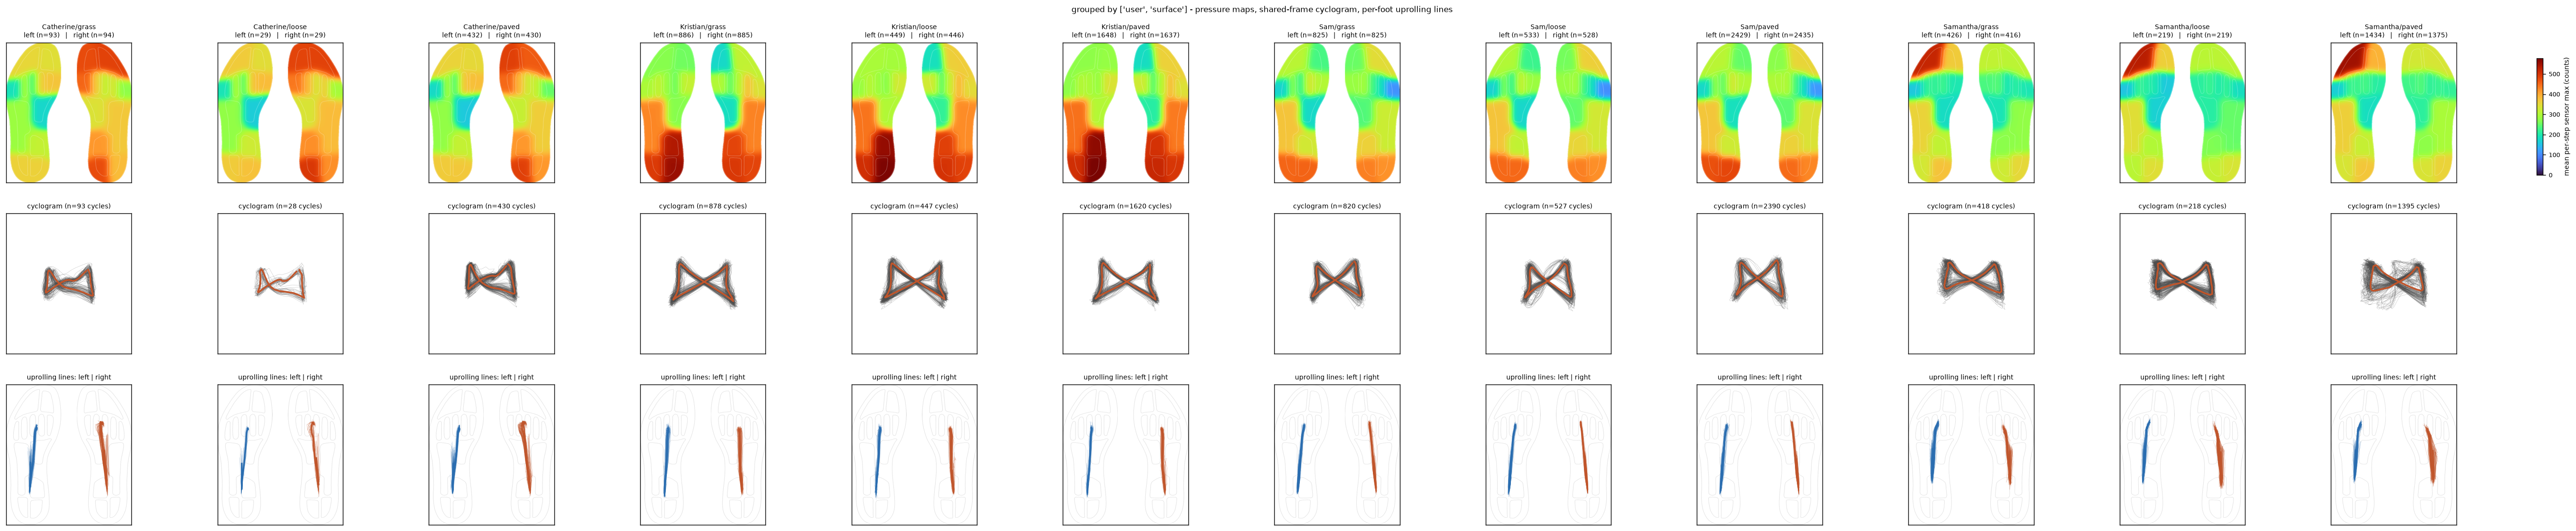

In [63]:
def group_keys(gb):
    if gb == 'overall':
        return [('overall', STEPS, CYCLES)]
    gb = [gb] if isinstance(gb, str) else list(gb)
    out = []
    for key, d in STEPS.groupby(gb, dropna=False):
        name = '/'.join(map(str, key)) if isinstance(key, tuple) else str(key)
        c = CYCLES
        for col, val in zip(gb, (key if isinstance(key, tuple) else (key,))):
            if col in CYCLES.columns:
                c = c[c[col] == val]
        out.append((name, d, c))
    return out


def pressure_map(d, side, kind='z'):
    cols = ZCOLS if kind == 'z' else RCOLS
    v = d[d['foot'] == side][cols].mean().to_numpy(float)
    return v


def blend(vals, side, sigma_px=18.0):
    if ZONES is None:
        return None
    f = np.zeros(ZONES.shape); w = np.zeros(ZONES.shape)
    for k in range(1, 13):
        m = ZONES == k
        f[m] = vals[k - 1]; w[m] = 1.0
    sv, sw = f.copy(), w.copy(); s = sigma_px / 3.0
    for _ in range(6):
        num = ndi.gaussian_filter(f * w, s, mode='nearest')
        den = ndi.gaussian_filter(w, s, mode='nearest')
        f = np.where(sw > 0, sv, num / np.maximum(den, 1e-9))
        w = ((den > 1e-6) | (sw > 0)).astype(float); s *= 1.6
        if w[SOLE].min() > 0:
            break
    num = ndi.gaussian_filter(f * w, sigma_px, mode='nearest')
    den = ndi.gaussian_filter(w, sigma_px, mode='nearest')
    out = num / np.maximum(den, 1e-9)
    out[~SOLE] = np.nan
    return out if side == 'left' else out[:, ::-1]


# ALIGN_ROWS=True draws every panel on the same physical frame, so the three rows line
# up vertically and the cyclogram is to scale against the insoles. False lets the
# cyclogram autoscale to fill its panel, at the cost of the alignment.
ALIGN_ROWS = True


# Identical frame and identical box shape for every panel.
# aspect='equal' is what keeps the insoles undistorted, and with the colourbar moved out
# of the grid every slot is the same size, so the shrunk-to-fit boxes are identical and
# centred in their slots - which is what makes the rows line up. An earlier attempt
# padded the DATA limits to the slot aspect instead; that aligned the boxes but stretched
# the insoles, because get_position() at build time does not match the final layout once
# bbox_inches='tight' is applied on save.
def _frame(ax, tight=False, centre_on=None):
    ax.set_xticks([]); ax.set_yticks([])
    if tight and not ALIGN_ROWS:
        ax.set_aspect('equal')
        return
    # Same extent for every panel, so the boxes match and the rows line up. centre_on
    # slides that window so the given content sits in the middle of it, without changing
    # the size or the scale - which is how the butterfly ends up centred while staying
    # to scale against the insoles.
    cx, cy = FRAME_W / 2, FRAME_H / 2
    if centre_on is not None:
        X, Y = centre_on
        cx = (float(np.nanmin(X)) + float(np.nanmax(X))) / 2
        cy = (float(np.nanmin(Y)) + float(np.nanmax(Y))) / 2
    ax.set_xlim(cx - FRAME_W / 2, cx + FRAME_W / 2)
    ax.set_ylim(cy - FRAME_H / 2, cy + FRAME_H / 2)
    ax.set_aspect('equal', adjustable='box', anchor='C')


# Centre the butterfly and let it fill its panel, WITHOUT breaking the column
# alignment. The trick is to keep the limits at the same aspect ratio as the insole
# frame: aspect='equal' then shrinks the box to exactly the same shape as the panels
# above and below, so the boxes still match while the data range is much smaller.
# Consequence: the cyclogram is no longer to scale against the insoles, so a scale bar
# is drawn to keep the physical size readable.
# CYCLO_ZOOM=False draws the butterfly on the shared insole frame, so it is TO SCALE
# against the insoles above it and every panel uses one scale. True zooms each panel to
# its own butterfly, which fills the box but gives each panel a different scale - set
# CYCLO_SCALEBAR with it so the size stays readable.
CYCLO_ZOOM = False
CYCLO_PAD = 1.12          # with CYCLO_ZOOM: extra room around the butterfly
CYCLO_SCALEBAR = True     # with CYCLO_ZOOM: draw a mm scale bar, since scales differ


def _zoom_frame(ax, X, Y):
    tgt = FRAME_W / FRAME_H
    x0, x1 = float(np.nanmin(X)), float(np.nanmax(X))
    y0, y1 = float(np.nanmin(Y)), float(np.nanmax(Y))
    cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
    w, h = max(x1 - x0, 1e-6) * CYCLO_PAD, max(y1 - y0, 1e-6) * CYCLO_PAD
    if w / h < tgt:
        w = h * tgt
    else:
        h = w / tgt
    ax.set_xlim(cx - w / 2, cx + w / 2)
    ax.set_ylim(cy - h / 2, cy + h / 2)
    ax.set_aspect('equal', adjustable='box', anchor='C')
    ax.set_xticks([]); ax.set_yticks([])
    if CYCLO_SCALEBAR:
        bar = max(10, round(w / 5 / 10) * 10)        # a round number of mm
        bx = cx - w / 2 + 0.06 * w
        by = cy - h / 2 + 0.07 * h
        ax.plot([bx, bx + bar], [by, by], color='0.25', lw=1.6,
                solid_capstyle='butt', zorder=9)
        ax.text(bx + bar / 2, by + 0.015 * h, f'{bar:.0f} mm', ha='center',
                va='bottom', fontsize=6.5, color='0.25', zorder=9)


def draw_insole(ax, vals, side, vmin, vmax, dx=0.0):
    """Draw one insole at horizontal offset dx, so both feet can share an axes."""
    ext = [dx, dx + SOLE_W_MM, 0, SOLE_L_MM]
    fld = blend(vals, side)
    if fld is not None:
        im = ax.imshow(fld, origin='upper', cmap='turbo', vmin=vmin, vmax=vmax,
                       extent=ext, interpolation='bilinear')
        al = ALPHA if side == 'left' else ALPHA[:, ::-1]
        ax.imshow(np.dstack([np.ones(al.shape)] * 3 + [al / 255.0 * 0.9]),
                  origin='upper', extent=ext)
    else:
        C = COORDS[side]
        im = ax.scatter(dx + C[:, 0] * SOLE_W_MM, C[:, 1] * SOLE_L_MM,
                        s=20 + 380 * vals / max(vmax, 1e-9), c=vals, cmap='turbo',
                        vmin=vmin, vmax=vmax)
    return im


def cop_paths(d, side):
    """Per-step CoP paths for one foot: (n_steps, COP_N, 2) in normalised coords."""
    sub = d[d['foot'] == side]
    if sub.empty:
        return np.empty((0, COP_N, 2))
    return np.stack([np.column_stack([x, y])
                     for x, y in zip(sub['cop_x'], sub['cop_y'])])


GROUPS = group_keys(GROUP_BY)
vmax = max(np.nanmax(pressure_map(d, s)) for _, d, _ in GROUPS
           for s in ('left', 'right') if len(d[d['foot'] == s]))
ncol = len(GROUPS)
DX = SOLE_W_MM + GAP_MM          # offset of the right insole within a shared axes
FRAME_W = DX + SOLE_W_MM         # every panel uses this x extent, so the three rows
FRAME_H = SOLE_L_MM              # share one box shape and line up vertically
# GridSpec with 4 column units per group (3 groups -> a 3x12 grid). Each panel spans all
# four, so a group's panels sit in one aligned column whatever ncol is.
import matplotlib.gridspec as _gs
UNITS = 4
PANEL_W = min(4.4, 42.0 / ncol)        # keep the figure a sane width as ncol grows
fig = plt.figure(figsize=(PANEL_W * ncol + 1.0, 8.6))
# right margin reserved for the colourbar, so it does NOT steal width from row 0
_grid = _gs.GridSpec(3, UNITS * ncol, figure=fig, hspace=0.22, wspace=0.25,
                     left=0.012, right=1 - 1.0 / (PANEL_W * ncol + 1.0) - 0.012,
                     top=0.93, bottom=0.02)
axes = np.empty((3, ncol), dtype=object)
for _i in range(3):
    for _j in range(ncol):
        axes[_i][_j] = fig.add_subplot(_grid[_i, _j * UNITS:(_j + 1) * UNITS])
for j, (name, d, c) in enumerate(GROUPS):
    # pressure maps: left and right side by side in one axes
    ax = axes[0][j]
    nL = int((d['foot'] == 'left').sum()); nR = int((d['foot'] == 'right').sum())
    for side, dx in (('left', 0.0), ('right', DX)):
        im = draw_insole(ax, pressure_map(d, side), side, 0, vmax, dx=dx)
    ax.set_title(f'{name}\nleft (n={nL})   |   right (n={nR})', fontsize=8)
    _frame(ax)
    # butterfly: both soles, shared frame
    ax = axes[1][j]
    if len(c):
        X = np.stack(c['x'].to_numpy())
        Y = np.stack(c['y'].to_numpy())
        for k in range(0, len(X), max(1, len(X) // 120)):
            ax.plot(X[k], Y[k], color='0.3', lw=0.35, alpha=0.3)
        ax.plot(X.mean(0), Y.mean(0), color='#C0552B', lw=2.0)
        ax.set_title(f'cyclogram (n={len(X)} cycles)', fontsize=8)
        if CYCLO_ZOOM:
            _zoom_frame(ax, X, Y)
        else:
            _frame(ax, centre_on=(X, Y))
    else:
        ax.text(0.5, 0.5, 'no cycles', ha='center', va='center', transform=ax.transAxes,
                fontsize=8, color='0.5')
        _frame(ax)
    # per-foot uprolling lines: each foot on its OWN outline, side by side
    ax = axes[2][j]
    for side, dx, col in (('left', 0.0, '#2A6DB0'), ('right', DX, '#C0552B')):
        if ALPHA is not None:
            al = ALPHA if side == 'left' else ALPHA[:, ::-1]
            ax.imshow(np.dstack([np.zeros(al.shape)] * 3 + [al / 255.0 * 0.35]),
                      origin='upper', extent=[dx, dx + SOLE_W_MM, 0, SOLE_L_MM])
        pp = cop_paths(d, side)
        if len(pp):
            for k in range(0, len(pp), max(1, len(pp) // 90)):
                ax.plot(dx + pp[k, :, 0] * SOLE_W_MM, pp[k, :, 1] * SOLE_L_MM,
                        color=col, lw=0.35, alpha=0.3)
            m = np.nanmean(pp, axis=0)
            ax.plot(dx + m[:, 0] * SOLE_W_MM, m[:, 1] * SOLE_L_MM, color=col, lw=1.8)
    ax.set_title('uprolling lines: left | right', fontsize=8)
    _frame(ax)
# colourbar in its own axes in the reserved margin, so every panel keeps its full slot
_right = 1 - 1.0 / (PANEL_W * ncol + 1.0)
_cax = fig.add_axes([_right + 0.004, 0.68, 0.10 / (PANEL_W * ncol + 1.0), 0.22])
cb = fig.colorbar(im, cax=_cax)
cb.set_label('mean per-step sensor max (counts)', fontsize=7.5)
cb.ax.tick_params(labelsize=7)
fig.suptitle(f'grouped by {GROUP_BY} - pressure maps, shared-frame cyclogram, '
             f'per-foot uprolling lines', fontsize=9.5, y=0.999)
fig.savefig(OUT_DIR / 'group_maps.png', bbox_inches='tight')
fig.savefig(OUT_DIR / 'group_maps.svg', bbox_inches='tight')
plt.show()

## 8. Pressure distribution — this notebook's definition

Overall is reproducible: area-weighted raw average-of-maximum gives 47.0 / 46.1 / 47.0
across the three reference sessions against reported 47 / 46 / 48.

Medial/lateral and forefoot/hindfoot now use **stappone's own sensor groups**:

| group | sensors |
|---|---|
| forefoot | 1, 2, 4, 5, 6, 9, 12 |
| hindfoot | 8, 11 |
| medial | 2, 3, 5, 10 |
| lateral | 6, 7, 9 |

Each pair is a share of its own two groups, not of the whole foot — sensors 3, 7 and 10
sit in neither forefoot nor hindfoot, and 1, 4, 8, 11 and 12 in neither medial nor
lateral. The groups cross-check cleanly against the published coordinates (every
forefoot sensor above y = 0.6, both hindfoot sensors below y = 0.2, every medial sensor
on the high-x side and every lateral one on the low-x side), which independently
confirms the sensor numbering and the left/right convention used here.

**They still do not reproduce the reported values.** On the three reference sessions a
plain share of the average-of-maximum map gives forefoot 66-75 % against reported
5-26 %, and medial 56-66 % against reported 15-52 %. The grouping was not the missing
piece: with 7 forefoot sensors against 2 at the heel, a plain sum makes the forefoot
dominate, and the reported numbers invert that.

stappone note that the web values are "post-processed, including filtering and
rounding", and that filtering is doing the work. It must also be **session-dependent**:
the computed shares here move by 1-2 points across the three recordings while the
reported ones move 13-25 (left medial 20 / 28 / 15). A single threshold parameter fitted
across all six foot-sessions leaves 153-211 points of total error. So the numbers below
are this notebook's own, on the vendor's groups; don't expect them to match the panel
until stappone say what the filter is.


In [64]:
GAINS = np.ones(12)      # per-sensor calibration, if stappone ever supplies it


def distribution(d):
    out, tot = {}, {}
    for side in ('left', 'right'):
        v = pressure_map(d, side) * GAINS
        raw = pressure_map(d, side, kind='r')
        tot[side] = (raw * AREAS).sum()
        if v.sum() <= 0:
            continue
        # each pair is a share of ITS OWN two groups, per stappone's grouping
        for a_nm, a, b_nm, b in (('forefoot', FOREFOOT, 'hindfoot', HINDFOOT),
                                 ('medial', MEDIAL, 'lateral', LATERAL)):
            x = v[[k - 1 for k in a]].sum(); y = v[[k - 1 for k in b]].sum()
            out[f'{side}_{a_nm}'] = 100 * x / (x + y) if x + y > 0 else np.nan
            out[f'{side}_{b_nm}'] = 100 * y / (x + y) if x + y > 0 else np.nan
    s = sum(tot.values())
    for side in tot:
        out[f'{side}_overall'] = 100 * tot[side] / s if s else np.nan
    return out


rows = {name: distribution(d) for name, d, _ in GROUPS}
rows['overall'] = distribution(STEPS)
DIST = pd.DataFrame(rows).T
print(DIST.round(1).to_string())

                 left_forefoot  left_hindfoot  left_medial  left_lateral  right_forefoot  right_hindfoot  right_medial  right_lateral  left_overall  right_overall
Catherine/grass           74.9           25.1         61.7          38.3            75.9            24.1          61.6           38.4          44.7           55.3
Catherine/loose           74.8           25.2         61.9          38.1            75.2            24.8          60.5           39.5          44.4           55.6
Catherine/paved           74.7           25.3         62.3          37.7            74.9            25.1          62.7           37.3          44.7           55.3
Kristian/grass            65.6           34.4         57.0          43.0            67.9            32.1          51.4           48.6          51.2           48.8
Kristian/loose            65.5           34.5         58.6          41.4            68.9            31.1          52.4           47.6          51.5           48.5
Kristian/paved        

## 9. Export

In [ ]:
STEPS.drop(columns=['cop_x', 'cop_y']).to_csv(OUT_DIR / 'steps_all.csv', index=False)
np.save(OUT_DIR / 'step_cop_paths.npy',
        np.stack([np.column_stack([x, y]) for x, y in zip(STEPS['cop_x'], STEPS['cop_y'])]))
RECS.to_csv(OUT_DIR / 'recordings.csv', index=False)
DIST.to_csv(OUT_DIR / 'pressure_distribution.csv')
for gb, nm in (('overall', 'overall'), ('user', 'by_user'), ('surface', 'by_surface'),
               (['user', 'surface'], 'by_user_surface'), ('stem', 'by_recording'),
               (['stem', 'surface'], 'by_recording_surface')):
    table(gb).to_csv(OUT_DIR / f'metrics_{nm}.csv')
np.save(OUT_DIR / 'cyclogram_x.npy', np.stack(CYCLES['x'].to_numpy()))
np.save(OUT_DIR / 'cyclogram_y.npy', np.stack(CYCLES['y'].to_numpy()))
CYCLES[['user', 'stem', 'surface']].to_csv(OUT_DIR / 'cyclogram_index.csv', index=False)

meta = dict(base=str(BASE.resolve()), recordings=int(len(FILES)),
            users=sorted(FILES['user'].unique().tolist()),
            steps_kept=int(len(STEPS)), gate=GATE,
            strict_gate=True, drop_unlabelled=DROP_UNLABELLED,
            events_used=bool(FILES['gc'].notna().all()),
            reg_source=REG_SOURCE, reg_trim_pct=REG_TRIM_PCT,
            group_by=GROUP_BY)
(OUT_DIR / 'run_meta.json').write_text(json.dumps(meta, indent=2, default=str))
print(json.dumps(meta, indent=2, default=str))
print('\nwrote:', *sorted(p.name for p in OUT_DIR.iterdir()), sep='\n  ')